In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuration

In [2]:
# Root directory containing benchmark results
RESULT_ROOT = Path("results")

# Output directory for figures
FIG_DIR = Path("fig")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Plot configuration
# -----------------------------

# Include cold download/build line if download_ms exists.
# Set False for directory benchmarks if large dirs were lookup-only.
INCLUDE_DOWNLOAD = True

# Use "log" or "linear"
Y_SCALE = "log"

# Error bar style: "iqr" or "std"
ERROR_STYLE = "iqr"

# Save both PDF and PNG
SAVE_FIGURES = True

# -----------------------------
# Benchmark profiles
# -----------------------------

SINGLE_PROFILE = "synthetic_single"

DIR_PROFILES = [
    "dir_10_mixed",
    "dir_100_mixed",
    "dir_1000_mixed",
    "dir_5000_mixed",
    "dir_10000_mixed",
]

# -----------------------------
# Colors
# -----------------------------

LINE_COLORS = {
    "total_lookup_ms": "#0072B2",          # blue
    "fingerprint_compute_ms": "#009E73",  # green
    "download_ms": "#E69F00",             # orange
}

LABELS = {
    "total_lookup_ms": "total lookup",
    "fingerprint_compute_ms": "hash compute",
    "download_ms": "cold cache build",
}

# Helpers

In [3]:
def format_size(nbytes):
    """Format byte counts for labels."""
    if pd.isna(nbytes):
        return "unknown"

    nbytes = float(nbytes)

    if nbytes >= 1024**3:
        return f"{nbytes / 1024**3:.1f} GB"
    if nbytes >= 1024**2:
        return f"{nbytes / 1024**2:.0f} MB"
    if nbytes >= 1024:
        return f"{nbytes / 1024:.0f} KB"
    return f"{nbytes:.0f} B"


def extract_run_number(path: Path):
    """Extract run number from run_10.json."""
    m = re.search(r"run_(\d+)", path.stem)
    return int(m.group(1)) if m else None


def load_benchmark_dir(result_dir: Path) -> pd.DataFrame:
    """
    Load all run_*.json files from a result directory.

    Each JSON has:
      - profile
      - items
      - timings:
          metadata_fetch_ms
          fingerprint_compute_ms
          total_lookup_ms
          download_ms
      - source_meta_summary:
          object_type
          size
          file_count
          total_size
    """
    rows = []

    json_files = sorted(result_dir.glob("run_*.json"), key=extract_run_number)

    if not json_files:
        print(f"[warning] No run_*.json files found in {result_dir}")

    for json_file in json_files:
        with json_file.open("r", encoding="utf-8") as f:
            report = json.load(f)

        run_number = extract_run_number(json_file)

        for item in report.get("items", []):
            timings = item.get("timings", {}) or {}
            meta = item.get("source_meta_summary", {}) or {}

            error = item.get("error")

            rows.append({
                "json_file": str(json_file),
                "run_number": run_number,
                "profile": report.get("profile"),
                "name": item.get("name"),
                "source_type": item.get("source_type"),
                "source": item.get("source"),
                "cache_hit": item.get("cache_hit"),
                "error": error,

                "object_type": meta.get("object_type"),
                "size_bytes": meta.get("size"),
                "file_count": meta.get("file_count"),
                "total_size_bytes": meta.get("total_size"),

                "metadata_fetch_ms": timings.get("metadata_fetch_ms"),
                "fingerprint_compute_ms": timings.get("fingerprint_compute_ms"),
                "total_lookup_ms": timings.get("total_lookup_ms"),
                "download_ms": timings.get("download_ms"),
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return df

    numeric_cols = [
        "run_number",
        "size_bytes",
        "file_count",
        "total_size_bytes",
        "metadata_fetch_ms",
        "fingerprint_compute_ms",
        "total_lookup_ms",
        "download_ms",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def summarize_metric(df: pd.DataFrame, group_cols, metric: str) -> pd.DataFrame:
    """Compute median, IQR, mean, std, and count for one metric."""
    def q1(x):
        x = x.dropna()
        return np.percentile(x, 25) if len(x) else np.nan

    def q3(x):
        x = x.dropna()
        return np.percentile(x, 75) if len(x) else np.nan

    out = (
        df.groupby(group_cols)[metric]
        .agg(
            median="median",
            q1=q1,
            q3=q3,
            mean="mean",
            std="std",
            count="count",
        )
        .reset_index()
    )

    out[f"{metric}_err_low_iqr"] = out["median"] - out["q1"]
    out[f"{metric}_err_high_iqr"] = out["q3"] - out["median"]
    out[f"{metric}_err_std"] = out["std"]

    return out.rename(columns={
        "median": f"{metric}_median",
        "mean": f"{metric}_mean",
        "std": f"{metric}_std",
        "count": f"{metric}_count",
        "q1": f"{metric}_q1",
        "q3": f"{metric}_q3",
    })


def metric_error(summary: pd.DataFrame, metric: str, style="iqr"):
    """Return yerr array for matplotlib errorbar."""
    if style == "iqr":
        return [
            summary[f"{metric}_err_low_iqr"].to_numpy(),
            summary[f"{metric}_err_high_iqr"].to_numpy(),
        ]

    if style == "std":
        err = summary[f"{metric}_err_std"].fillna(0).to_numpy()
        return [err, err]

    raise ValueError("style must be 'iqr' or 'std'")


def save_figure(fig, basename):
    """Save figure as PDF and PNG."""
    if not SAVE_FIGURES:
        return

    pdf = FIG_DIR / f"{basename}.pdf"
    png = FIG_DIR / f"{basename}.png"

    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=300, bbox_inches="tight")

    print("Saved:", pdf.resolve())
    print("Saved:", png.resolve())

# Single File

In [5]:
single_dir = RESULT_ROOT / SINGLE_PROFILE
single_raw = load_benchmark_dir(single_dir)

print("Rows:", len(single_raw))
single_raw.head()

Rows: 40


,json_file,run_number,profile,name,source_type,source,cache_hit,error,object_type,size_bytes,file_count,total_size_bytes,metadata_fetch_ms,fingerprint_compute_ms,total_lookup_ms,download_ms
0,results/synthetic_single/run_1.json,1,synthetic_single,single_1mb,s3,s3://floability/floability-cache-bench/single/...,False,None,file,1048576,NaN,NaN,133.60,0.07,133.67,487.91
1,results/synthetic_single/run_1.json,1,synthetic_single,single_10mb,s3,s3://floability/floability-cache-bench/single/...,False,None,file,10485760,NaN,NaN,125.26,0.09,125.35,671.64
2,results/synthetic_single/run_1.json,1,synthetic_single,single_100mb,s3,s3://floability/floability-cache-bench/single/...,False,None,file,104857600,NaN,NaN,140.98,0.05,141.03,3806.71
3,results/synthetic_single/run_1.json,1,synthetic_single,single_1gb,s3,s3://floability/floability-cache-bench/single/...,False,None,file,1073741824,NaN,NaN,124.25,0.05,124.30,109423.40
4,results/synthetic_single/run_2.json,2,synthetic_single,single_1mb,s3,s3://floability/floability-cache-bench/single/...,False,None,file,1048576,NaN,NaN,117.55,0.08,117.63,542.26


In [6]:
single_df = single_raw[single_raw["error"].isna()].copy()

# Use source metadata size for ordering.
single_df["size_label"] = single_df["size_bytes"].apply(format_size)

single_df = single_df.sort_values(["size_bytes", "run_number"]).reset_index(drop=True)

single_df[[
    "run_number",
    "name",
    "size_label",
    "metadata_fetch_ms",
    "fingerprint_compute_ms",
    "total_lookup_ms",
    "download_ms",
    "cache_hit",
]].head(20)

,run_number,name,size_label,metadata_fetch_ms,fingerprint_compute_ms,total_lookup_ms,download_ms,cache_hit
0,1,single_1mb,1 MB,133.60,0.07,133.67,487.91,False
1,2,single_1mb,1 MB,117.55,0.08,117.63,542.26,False
2,3,single_1mb,1 MB,113.17,0.12,113.29,450.18,False
3,4,single_1mb,1 MB,115.07,0.07,115.14,396.81,False
4,5,single_1mb,1 MB,132.92,0.09,133.01,418.76,False
5,6,single_1mb,1 MB,124.78,0.06,124.84,497.66,False
6,7,single_1mb,1 MB,117.05,0.07,117.12,507.32,False
7,8,single_1mb,1 MB,112.90,0.08,112.98,406.40,False
8,9,single_1mb,1 MB,156.51,0.07,156.58,491.84,False
9,10,single_1mb,1 MB,111.04,0.05,111.09,414.57,False


In [7]:
single_group_cols = ["name", "size_bytes", "size_label"]

single_lookup = summarize_metric(single_df, single_group_cols, "total_lookup_ms")
single_fp = summarize_metric(single_df, single_group_cols, "fingerprint_compute_ms")
single_download = summarize_metric(single_df, single_group_cols, "download_ms")

single_summary = (
    single_lookup
    .merge(single_fp, on=single_group_cols, how="left")
    .merge(single_download, on=single_group_cols, how="left")
    .sort_values("size_bytes")
    .reset_index(drop=True)
)

single_summary[[
    "name",
    "size_label",
    "total_lookup_ms_median",
    "fingerprint_compute_ms_median",
    "download_ms_median",
]]

,name,size_label,total_lookup_ms_median,fingerprint_compute_ms_median,download_ms_median
0,single_1mb,1 MB,117.375,0.070,469.045
1,single_10mb,10 MB,117.285,0.065,683.185
2,single_100mb,100 MB,119.300,0.060,2660.445
3,single_1gb,1.0 GB,118.180,0.060,30433.440


Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/single_file_cache_benchmark_log.pdf
Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/single_file_cache_benchmark_log.png


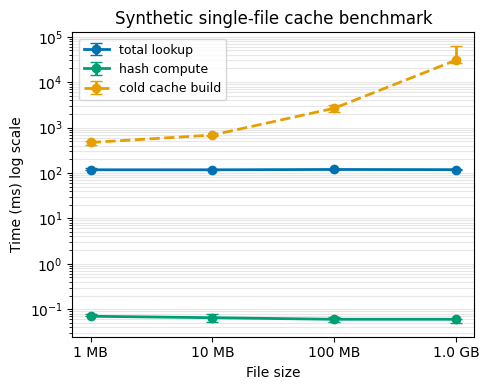

In [8]:
def plot_single_file_benchmark(
    single_summary,
    include_download=INCLUDE_DOWNLOAD,
    y_scale=Y_SCALE,
    error_style=ERROR_STYLE,
):
    fig, ax = plt.subplots(figsize=(5, 4))

    x = np.arange(len(single_summary))

    # Total lookup
    ax.errorbar(
        x,
        single_summary["total_lookup_ms_median"],
        yerr=metric_error(single_summary, "total_lookup_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["total_lookup_ms"],
        label=LABELS["total_lookup_ms"],
    )

    # Fingerprint compute
    ax.errorbar(
        x,
        single_summary["fingerprint_compute_ms_median"],
        yerr=metric_error(single_summary, "fingerprint_compute_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["fingerprint_compute_ms"],
        label=LABELS["fingerprint_compute_ms"],
    )

    # Optional download/cache-build
    if include_download and single_summary["download_ms_median"].notna().any():
        ax.errorbar(
            x,
            single_summary["download_ms_median"],
            yerr=metric_error(single_summary, "download_ms", error_style),
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            color=LINE_COLORS["download_ms"],
            label=LABELS["download_ms"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(single_summary["size_label"])
    ax.set_xlabel("File size")
    ax.set_ylabel("Time (ms)" + (" log scale" if y_scale == "log" else ""))

    if y_scale == "log":
        ax.set_yscale("log")

    ax.set_title("Synthetic single-file cache benchmark")
    ax.grid(axis="y", which="both", alpha=0.3)
    ax.legend(fontsize=9)

    fig.tight_layout()
    save_figure(fig, f"single_file_cache_benchmark_{y_scale}")

    plt.show()


plot_single_file_benchmark(single_summary)

# Directory

In [9]:
dir_frames = []

for profile in DIR_PROFILES:
    result_dir = RESULT_ROOT / profile
    df = load_benchmark_dir(result_dir)

    if not df.empty:
        df["profile"] = profile
        dir_frames.append(df)

dir_raw = pd.concat(dir_frames, ignore_index=True) if dir_frames else pd.DataFrame()

print("Rows:", len(dir_raw))
dir_raw.head()

Rows: 50


,json_file,run_number,profile,name,source_type,source,cache_hit,error,object_type,size_bytes,file_count,total_size_bytes,metadata_fetch_ms,fingerprint_compute_ms,total_lookup_ms,download_ms
0,results/dir_10_mixed/run_1.json,1,dir_10_mixed,dir_10_mixed,s3,s3://floability/floability-cache-bench/dirs/di...,False,None,directory,NaN,10,290766128,1995.24,0.27,1995.51,13591.67
1,results/dir_10_mixed/run_2.json,2,dir_10_mixed,dir_10_mixed,s3,s3://floability/floability-cache-bench/dirs/di...,False,None,directory,NaN,10,290766128,1002.17,0.31,1002.48,10901.75
2,results/dir_10_mixed/run_3.json,3,dir_10_mixed,dir_10_mixed,s3,s3://floability/floability-cache-bench/dirs/di...,False,None,directory,NaN,10,290766128,1043.30,0.30,1043.60,9266.26
3,results/dir_10_mixed/run_4.json,4,dir_10_mixed,dir_10_mixed,s3,s3://floability/floability-cache-bench/dirs/di...,False,None,directory,NaN,10,290766128,3188.80,0.27,3189.07,17500.63
4,results/dir_10_mixed/run_5.json,5,dir_10_mixed,dir_10_mixed,s3,s3://floability/floability-cache-bench/dirs/di...,False,None,directory,NaN,10,290766128,1776.69,0.33,1777.02,10694.84


In [10]:
dir_df = dir_raw[dir_raw["error"].isna()].copy()

# Prefer actual metadata file_count, but profile names also encode count.
def file_count_from_profile(profile):
    m = re.search(r"dir_(\d+)_mixed", str(profile))
    return int(m.group(1)) if m else np.nan

dir_df["profile_file_count"] = dir_df["profile"].apply(file_count_from_profile)
dir_df["file_count_plot"] = dir_df["file_count"].fillna(dir_df["profile_file_count"])

# For directories, total size is in source_meta_summary["total_size"].
dir_df["total_size_label"] = dir_df["total_size_bytes"].apply(format_size)

dir_df = dir_df.sort_values(["file_count_plot", "run_number"]).reset_index(drop=True)

dir_df[[
    "run_number",
    "profile",
    "file_count_plot",
    "total_size_label",
    "metadata_fetch_ms",
    "fingerprint_compute_ms",
    "total_lookup_ms",
    "download_ms",
]].head(20)

,run_number,profile,file_count_plot,total_size_label,metadata_fetch_ms,fingerprint_compute_ms,total_lookup_ms,download_ms
0,1,dir_10_mixed,10,277 MB,1995.24,0.27,1995.51,13591.67
1,2,dir_10_mixed,10,277 MB,1002.17,0.31,1002.48,10901.75
2,3,dir_10_mixed,10,277 MB,1043.30,0.30,1043.60,9266.26
3,4,dir_10_mixed,10,277 MB,3188.80,0.27,3189.07,17500.63
4,5,dir_10_mixed,10,277 MB,1776.69,0.33,1777.02,10694.84
5,6,dir_10_mixed,10,277 MB,1085.36,0.30,1085.66,13100.51
6,7,dir_10_mixed,10,277 MB,1259.50,0.37,1259.87,8074.87
7,8,dir_10_mixed,10,277 MB,1088.31,0.26,1088.57,13463.85
8,9,dir_10_mixed,10,277 MB,1036.95,0.27,1037.22,20023.56
9,10,dir_10_mixed,10,277 MB,1874.92,0.32,1875.24,6894.40


In [11]:
dir_group_cols = ["profile", "file_count_plot"]

dir_lookup = summarize_metric(dir_df, dir_group_cols, "total_lookup_ms")
dir_fp = summarize_metric(dir_df, dir_group_cols, "fingerprint_compute_ms")
dir_download = summarize_metric(dir_df, dir_group_cols, "download_ms")

# Metadata columns for labels
dir_meta = (
    dir_df.groupby(dir_group_cols, as_index=False)
    .agg(
        total_size_bytes=("total_size_bytes", "median"),
        n_runs=("run_number", "count"),
    )
)

dir_summary = (
    dir_lookup
    .merge(dir_fp, on=dir_group_cols, how="left")
    .merge(dir_download, on=dir_group_cols, how="left")
    .merge(dir_meta, on=dir_group_cols, how="left")
    .sort_values("file_count_plot")
    .reset_index(drop=True)
)

dir_summary["total_size_label"] = dir_summary["total_size_bytes"].apply(format_size)

dir_summary[[
    "profile",
    "file_count_plot",
    "total_size_label",
    "total_lookup_ms_median",
    "fingerprint_compute_ms_median",
    "download_ms_median",
]]

,profile,file_count_plot,total_size_label,total_lookup_ms_median,fingerprint_compute_ms_median,download_ms_median
0,dir_10_mixed,10,277 MB,1174.220,0.300,12001.13
1,dir_100_mixed,100,2.2 GB,1980.215,0.485,120167.83
2,dir_1000_mixed,1000,12.5 GB,2148.775,2.225,631102.83
3,dir_5000_mixed,5000,68.5 GB,3088.360,11.180,3249686.24
4,dir_10000_mixed,10000,134.0 GB,4272.585,23.530,6945711.02


Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/directory_cache_benchmark_log.pdf
Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/directory_cache_benchmark_log.png


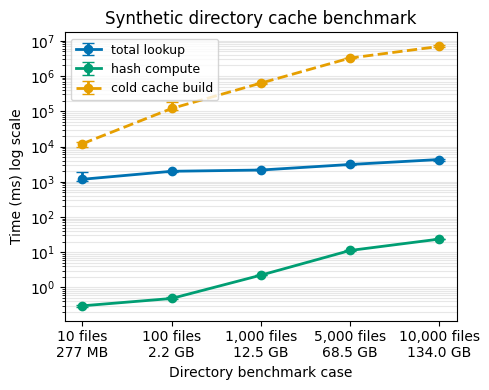

In [12]:
def plot_directory_benchmark(
    dir_summary,
    include_download=False,
    y_scale=Y_SCALE,
    error_style=ERROR_STYLE,
):
    fig, ax = plt.subplots(figsize=(5, 4))

    x = np.arange(len(dir_summary))

    xlabels = [
        f"{int(row.file_count_plot):,} files\n{row.total_size_label}"
        for row in dir_summary.itertuples()
    ]

    # Total lookup
    ax.errorbar(
        x,
        dir_summary["total_lookup_ms_median"],
        yerr=metric_error(dir_summary, "total_lookup_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["total_lookup_ms"],
        label=LABELS["total_lookup_ms"],
    )

    # Fingerprint compute
    ax.errorbar(
        x,
        dir_summary["fingerprint_compute_ms_median"],
        yerr=metric_error(dir_summary, "fingerprint_compute_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["fingerprint_compute_ms"],
        label=LABELS["fingerprint_compute_ms"],
    )

    # Optional cold cache build
    if include_download and dir_summary["download_ms_median"].notna().any():
        ax.errorbar(
            x,
            dir_summary["download_ms_median"],
            yerr=metric_error(dir_summary, "download_ms", error_style),
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            color=LINE_COLORS["download_ms"],
            label=LABELS["download_ms"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Directory benchmark case")
    ax.set_ylabel("Time (ms)" + (" log scale" if y_scale == "log" else ""))

    if y_scale == "log":
        ax.set_yscale("log")

    ax.set_title("Synthetic directory cache benchmark")
    ax.grid(axis="y", which="both", alpha=0.3)
    ax.legend(fontsize=9)

    fig.tight_layout()
    save_figure(fig, f"directory_cache_benchmark_{y_scale}")

    plt.show()


# Directory download/build likely incomplete, so default False here.
plot_directory_benchmark(dir_summary, include_download=True)

# Combined

Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/combined_cache_benchmark_log.pdf
Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/combined_cache_benchmark_log.png


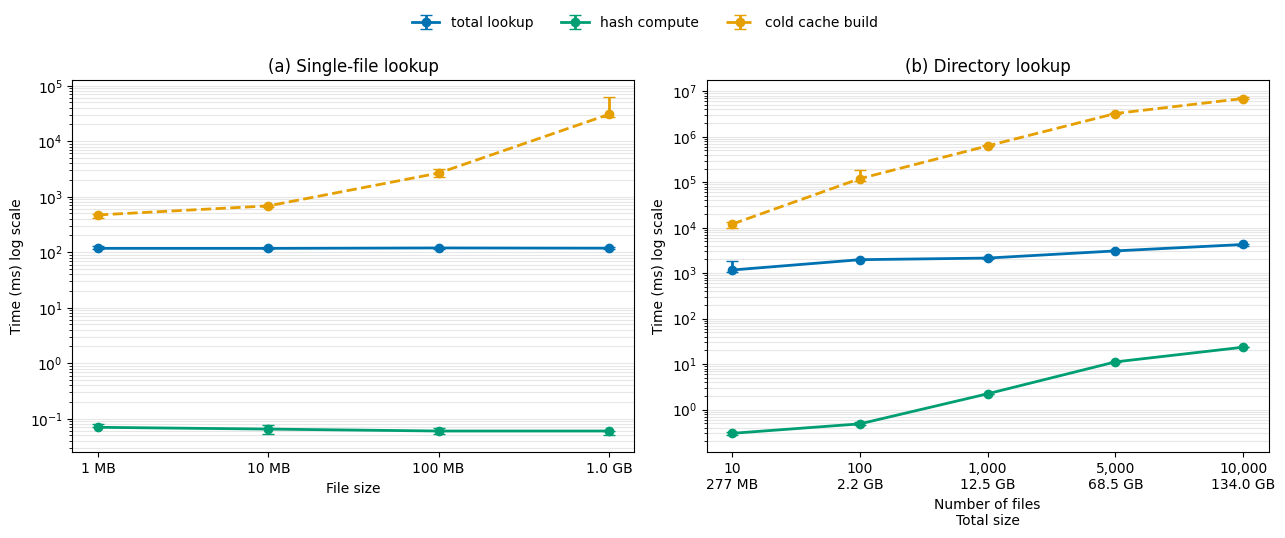

In [13]:
def plot_combined_paper_figure(
    single_summary,
    dir_summary,
    include_download_single=True,
    include_download_dir=False,
    y_scale="log",
    error_style=ERROR_STYLE,
):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(13.0, 5.0),
        sharey=False,
    )

    # -----------------------------
    # Panel A: single file
    # -----------------------------
    ax = axes[0]
    x = np.arange(len(single_summary))

    ax.errorbar(
        x,
        single_summary["total_lookup_ms_median"],
        yerr=metric_error(single_summary, "total_lookup_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["total_lookup_ms"],
        label=LABELS["total_lookup_ms"],
    )

    ax.errorbar(
        x,
        single_summary["fingerprint_compute_ms_median"],
        yerr=metric_error(single_summary, "fingerprint_compute_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["fingerprint_compute_ms"],
        label=LABELS["fingerprint_compute_ms"],
    )

    if include_download_single and single_summary["download_ms_median"].notna().any():
        ax.errorbar(
            x,
            single_summary["download_ms_median"],
            yerr=metric_error(single_summary, "download_ms", error_style),
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            color=LINE_COLORS["download_ms"],
            label=LABELS["download_ms"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(single_summary["size_label"])
    ax.set_xlabel("File size")
    ax.set_title("(a) Single-file lookup")

    if y_scale == "log":
        ax.set_yscale("log")

    ax.set_ylabel("Time (ms)" + (" log scale" if y_scale == "log" else ""))
    ax.grid(axis="y", which="both", alpha=0.3)

    # -----------------------------
    # Panel B: directory
    # -----------------------------
    ax = axes[1]
    x = np.arange(len(dir_summary))

    dir_labels = [
        f"{int(row.file_count_plot):,}\n{row.total_size_label}"
        for row in dir_summary.itertuples()
    ]

    ax.errorbar(
        x,
        dir_summary["total_lookup_ms_median"],
        yerr=metric_error(dir_summary, "total_lookup_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["total_lookup_ms"],
        label=LABELS["total_lookup_ms"],
    )

    ax.errorbar(
        x,
        dir_summary["fingerprint_compute_ms_median"],
        yerr=metric_error(dir_summary, "fingerprint_compute_ms", error_style),
        marker="o",
        linewidth=2,
        capsize=4,
        color=LINE_COLORS["fingerprint_compute_ms"],
        label=LABELS["fingerprint_compute_ms"],
    )

    if include_download_dir and dir_summary["download_ms_median"].notna().any():
        ax.errorbar(
            x,
            dir_summary["download_ms_median"],
            yerr=metric_error(dir_summary, "download_ms", error_style),
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            color=LINE_COLORS["download_ms"],
            label=LABELS["download_ms"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(dir_labels)
    ax.set_xlabel("Number of files\nTotal size")
    ax.set_title("(b) Directory lookup")

    if y_scale == "log":
        ax.set_yscale("log")

    ax.set_ylabel("Time (ms)" + (" log scale" if y_scale == "log" else ""))
    ax.grid(axis="y", which="both", alpha=0.3)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 1.08),
        frameon=False,
    )

    fig.tight_layout()

    save_figure(fig, f"combined_cache_benchmark_{y_scale}")

    plt.show()


plot_combined_paper_figure(
    single_summary,
    dir_summary,
    include_download_single=True,
    include_download_dir=True,
    y_scale=Y_SCALE,
)

Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/single_file_cache_benchmark_linear.pdf
Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/single_file_cache_benchmark_linear.png


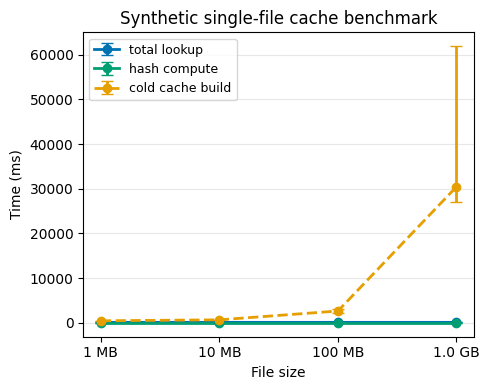

Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/directory_cache_benchmark_linear.pdf
Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/directory_cache_benchmark_linear.png


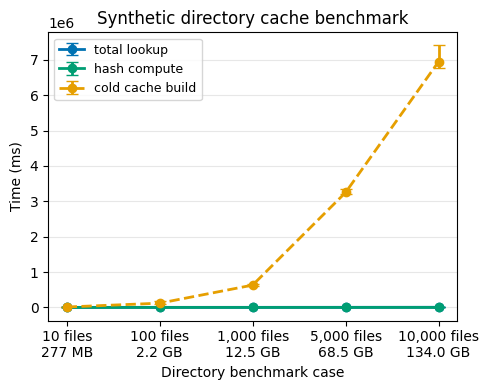

Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/combined_cache_benchmark_linear.pdf
Saved: /groups/dthain/users/mislam5/benchmark-data/floability-data-experiments/synthetic-data-benchmark/fig/combined_cache_benchmark_linear.png


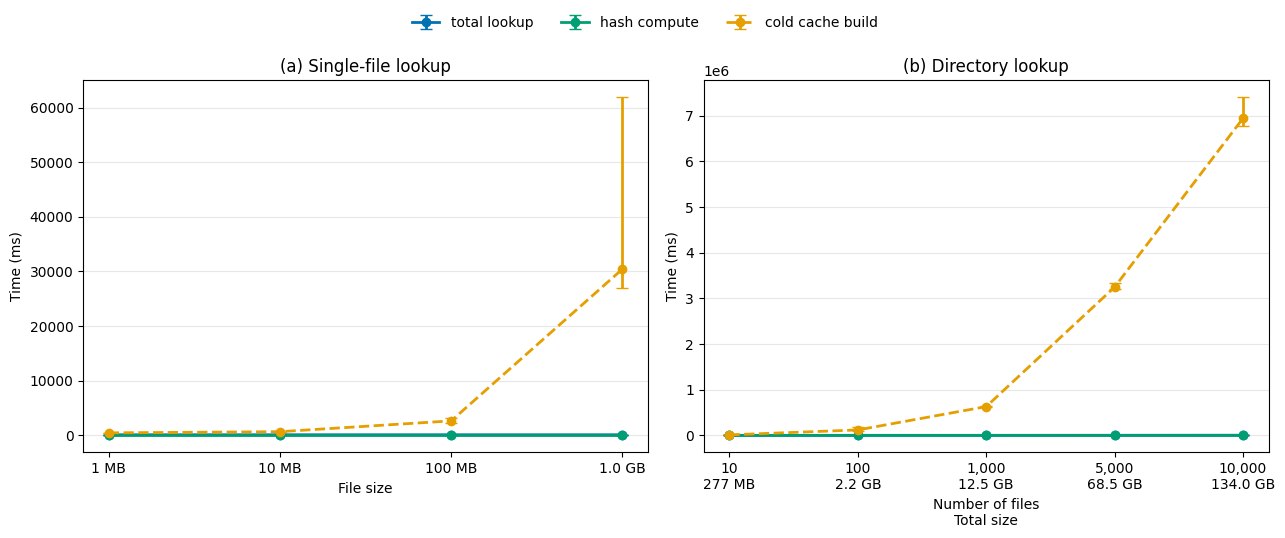

In [14]:
plot_single_file_benchmark(
    single_summary,
    include_download=True,
    y_scale="linear",
)

plot_directory_benchmark(
    dir_summary,
    include_download=True,
    y_scale="linear",
)

plot_combined_paper_figure(
    single_summary,
    dir_summary,
    include_download_single=True,
    include_download_dir=True,
    y_scale="linear",
)